# Notebook 1 — Embedding Space Visualisation

Plots the 20 SOC playbook embeddings in 2D using UMAP, coloured by severity and MITRE tactic.
Also shows where a set of test alert queries land in the same space.

**Prerequisites:** `python ingest.py` must have been run so `chroma_store/` exists.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import chromadb
import umap
import rag

client = chromadb.PersistentClient(path='../chroma_store')
collection = client.get_collection(rag.COLLECTION)
print(f'Collection has {collection.count()} documents')

Collection has 20 documents


In [2]:
# Fetch all embeddings and metadata
result = collection.get(include=['embeddings', 'metadatas', 'documents'])
embeddings = np.array(result['embeddings'])
metadatas  = result['metadatas']
ids        = result['ids']

titles     = [m['title'] for m in metadatas]
severities = [m.get('severity', 'UNKNOWN') for m in metadatas]

print(f'Loaded {len(embeddings)} embeddings of dimension {embeddings.shape[1]}')
print('Severity distribution:', {s: severities.count(s) for s in set(severities)})

Loaded 20 embeddings of dimension 768
Severity distribution: {'MEDIUM': 2, 'CRITICAL': 7, 'HIGH': 11}


In [3]:
# Reduce to 2D with UMAP
reducer = umap.UMAP(n_components=2, n_neighbors=5, min_dist=0.3,
                    metric='cosine', random_state=42)
embedding_2d = reducer.fit_transform(embeddings)
print('UMAP projection shape:', embedding_2d.shape)

C:\Users\vacha\OneDrive\Internship\rag-soc-assistant\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP projection shape: (20, 2)


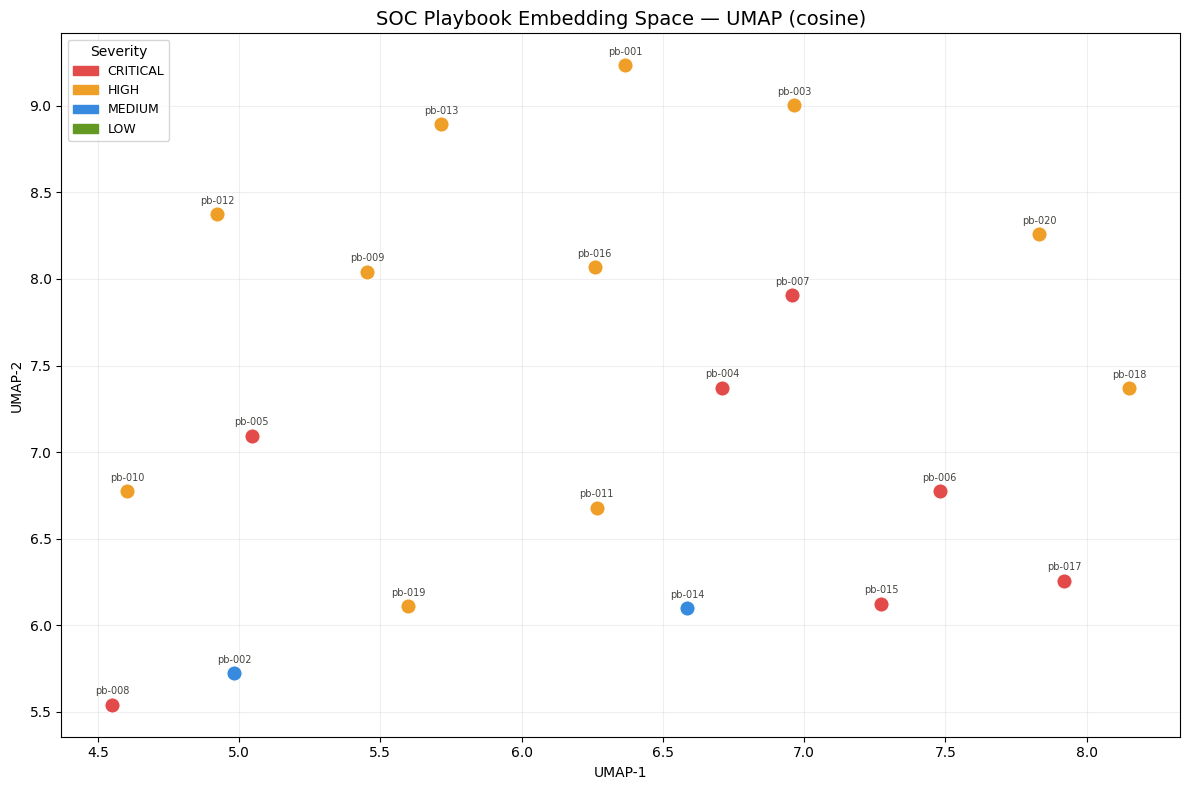

Saved: eval/embedding_space_severity.png


In [4]:
# Plot coloured by severity
sev_colors = {'CRITICAL': '#E24B4A', 'HIGH': '#EF9F27', 'MEDIUM': '#378ADD', 'LOW': '#639922'}

fig, ax = plt.subplots(figsize=(12, 8))

for i, (x, y) in enumerate(embedding_2d):
    sev   = severities[i]
    color = sev_colors.get(sev, '#888780')
    ax.scatter(x, y, c=color, s=120, zorder=3, edgecolors='white', linewidths=0.8)
    ax.annotate(
        ids[i],
        (x, y), fontsize=7, ha='center', va='bottom',
        xytext=(0, 6), textcoords='offset points', color='#444441'
    )

legend_handles = [mpatches.Patch(color=c, label=s) for s, c in sev_colors.items()]
ax.legend(handles=legend_handles, title='Severity', loc='upper left', fontsize=9)
ax.set_title('SOC Playbook Embedding Space — UMAP (cosine)', fontsize=14)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('../eval/embedding_space_severity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eval/embedding_space_severity.png')

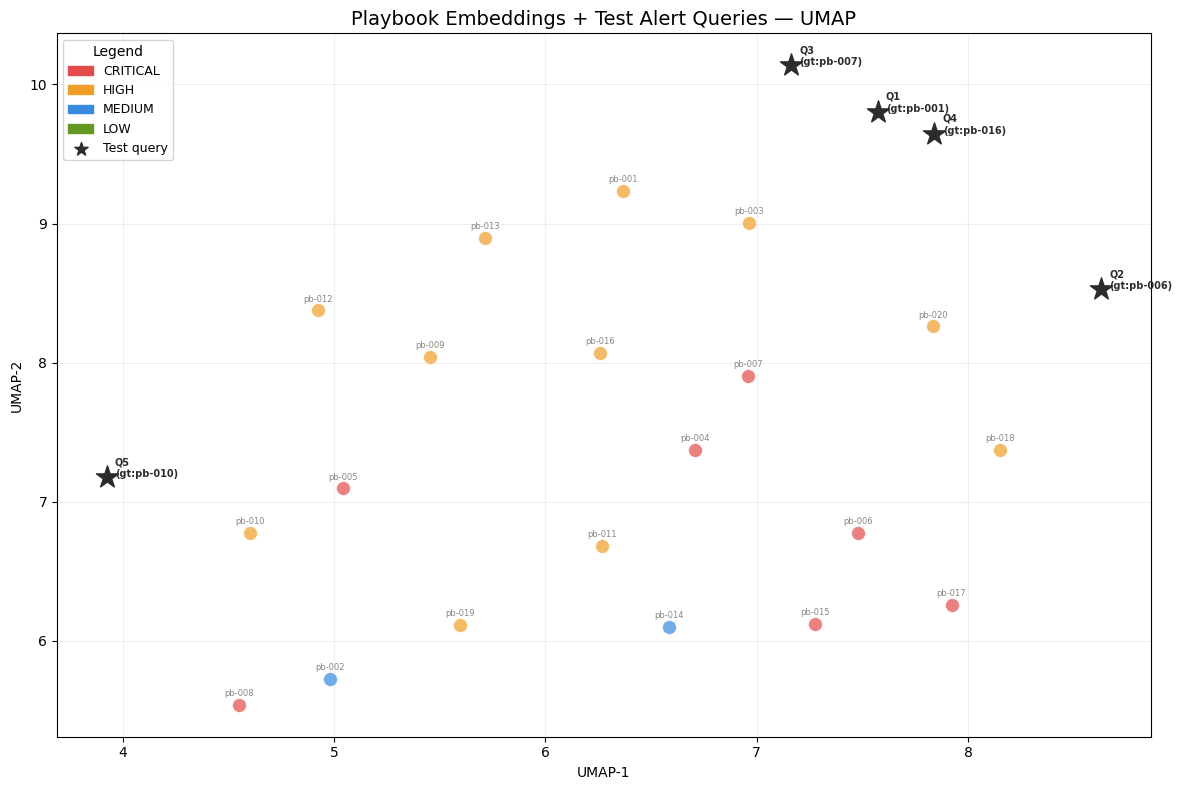

Saved: eval/embedding_space_with_queries.png


In [5]:
# Overlay 5 test alert queries
test_alerts = [
    ('SSH brute force: 87 failures from 45.33.32.156 targeting root', 'pb-001'),
    ('Ransomware: mass .encrypted file rename + VSS deletion', 'pb-006'),
    ('Pass-the-Hash lateral movement across 3 hosts', 'pb-007'),
    ('Kerberoasting: 47 TGS tickets in 90s', 'pb-016'),
    ('DNS tunneling: 60-char subdomains + TXT payload', 'pb-010'),
]

query_vecs = []
for alert_text, _ in test_alerts:
    vec = rag.embed(alert_text)
    query_vecs.append(vec)

query_2d = reducer.transform(np.array(query_vecs))

fig, ax = plt.subplots(figsize=(12, 8))
for i, (x, y) in enumerate(embedding_2d):
    color = sev_colors.get(severities[i], '#888780')
    ax.scatter(x, y, c=color, s=100, zorder=2, edgecolors='white', linewidths=0.6, alpha=0.7)
    ax.annotate(ids[i], (x, y), fontsize=6, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points', color='#888780')

for j, ((x, y), (alert_text, gt_id)) in enumerate(zip(query_2d, test_alerts)):
    ax.scatter(x, y, marker='*', s=280, c='#2C2C2A', zorder=5)
    ax.annotate(f'Q{j+1}\n(gt:{gt_id})', (x, y), fontsize=7, ha='left',
                xytext=(6, 0), textcoords='offset points', color='#2C2C2A', fontweight='bold')

legend_handles = [mpatches.Patch(color=c, label=s) for s, c in sev_colors.items()]
legend_handles.append(plt.scatter([], [], marker='*', c='#2C2C2A', s=100, label='Test query'))
ax.legend(handles=legend_handles, title='Legend', loc='upper left', fontsize=9)
ax.set_title('Playbook Embeddings + Test Alert Queries — UMAP', fontsize=14)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('../eval/embedding_space_with_queries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eval/embedding_space_with_queries.png')